# Agent turning

In [1]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


In [3]:
data_folder = '/Users/benny/swc/agents/data/split_cost_results_260707'
solo_files = identify_filepaths.get_relative_paths('solo', data_folder)

In [4]:
df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

IntProgress(value=0, max=45)

filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_0/2026-06-25_22-38-05_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_1/2026-06-26_04-04-58_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_2/2026-06-26_09-30-23_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_4/2026-06-26_20-22-51_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_5/2026-06-27_01-51-03_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_6/2026-06-27_07-15-15_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_7/2026-06-27_12-44-07_solo.json
Loading complete.
Pr

In [5]:
dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

In [6]:
dropped_trials = 1
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

In [7]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

In [8]:
import agent_analysis.functions.preprocessing as prep

_, step_penalties, thetas = prep.extract_step_penalties(data_folder, yaml_filename=None)
len(thetas)

No YAML file in add_later
No YAML file in excluded


45

## Turning magnitude after slice onset
how much the agent rotates in a fixed early window after slice onset

In [9]:
player_id = 0

Extract head angles from slice onset to trigger activation. 

Note that the function extracts them in radians

In [10]:
head_angles_sessions = {}

for session_id, trial_list in enumerate(trial_lists):
    head_angles_trials = {}

    for trial_index, trial in enumerate(trial_list):
        head_angles = trajectory_vectors.extract_trial_player_headangles(
            trial_list,
            trial_index,
            trial,
            player_id
        )

        head_angles_trials[trial_index] = np.asarray(
            head_angles,
            dtype=float
        )

    head_angles_sessions[session_id] = head_angles_trials

In [11]:
time_window = 10

In [12]:
turning_magnitude_dict = {}
mean_turning_magnitude_dict = {}

for session_id, trials in head_angles_sessions.items():
    session_turning = []

    for trial_id, angles_rad in trials.items():
        angles_window = np.asarray(
            angles_rad[:time_window],
            dtype=float
        )

        # Remove missing values
        angles_window = angles_window[~np.isnan(angles_window)]

        # At least two angles are required to calculate a difference
        if len(angles_window) < 2:
            session_turning.append(np.nan)
            continue

        # Unwrap in radians, then convert to degrees
        angles_unwrapped_deg = np.rad2deg(
            np.unwrap(angles_window)
        )

        # Frame-to-frame angular changes
        angle_diffs = np.diff(angles_unwrapped_deg)

        # Total absolute turning in the early window
        total_turning = np.sum(np.abs(angle_diffs))

        session_turning.append(total_turning)

    turning_magnitude_dict[session_id] = session_turning
    mean_turning_magnitude_dict[session_id] = np.nanmean(
        session_turning
    )

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_66483/219618413.py:35: RuntimeWarning: Mean of empty slice
  mean_turning_magnitude_dict[session_id] = np.nanmean(


In [13]:
thetas_array = np.asarray(thetas, dtype=float)

translation_costs = thetas_array[:, 0]
turning_costs = thetas_array[:, 1]

if np.any(translation_costs <= 0) or np.any(turning_costs <= 0):
    raise ValueError(
        "Translation and turning costs must be positive "
        "to compute a log-ratio."
    )

log_ratios = np.log2(
    translation_costs / turning_costs
)

equal_window = 0.5

ratio_group_labels = np.where(
    log_ratios < -equal_window,
    "Low ratio",
    np.where(
        log_ratios <= equal_window,
        "Around equal",
        "High ratio"
    )
)

In [14]:
group_order = [
    "Low ratio",
    "Around equal",
    "High ratio"
]

turning_by_group = {
    group: []
    for group in group_order
}

for session_id, group_label in enumerate(ratio_group_labels):
    mean_turning = mean_turning_magnitude_dict.get(
        session_id,
        np.nan
    )

    if not np.isnan(mean_turning):
        turning_by_group[group_label].append(mean_turning)

In [15]:
group_means = []
group_sems = []
group_counts = []

for group in group_order:
    values = np.asarray(
        turning_by_group[group],
        dtype=float
    )

    values = values[~np.isnan(values)]
    n_sessions = len(values)

    group_counts.append(n_sessions)

    if n_sessions == 0:
        group_means.append(np.nan)
        group_sems.append(np.nan)
    elif n_sessions == 1:
        group_means.append(values[0])
        group_sems.append(np.nan)
    else:
        group_means.append(np.mean(values))
        group_sems.append(
            np.std(values, ddof=1) / np.sqrt(n_sessions)
        )

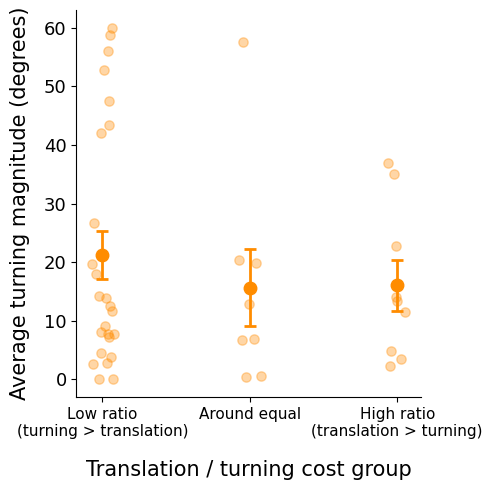

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))

x_positions = np.arange(len(group_order))

# Individual session means
rng = np.random.default_rng(42)

for x, group in zip(x_positions, group_order):
    values = np.asarray(
        turning_by_group[group],
        dtype=float
    )

    jitter = rng.uniform(-0.08, 0.08, size=len(values))

    ax.scatter(
        np.full(len(values), x) + jitter,
        values,
        color="darkorange",
        alpha=0.35,
        s=45,
        zorder=2
    )

# Group mean ± SEM
ax.errorbar(
    x_positions,
    group_means,
    yerr=group_sems,
    fmt="o",
    color="darkorange",
    ecolor="darkorange",
    markersize=9,
    elinewidth=2,
    capsize=4,
    capthick=2,
    zorder=3
)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    [
        "Low ratio\n(turning > translation)",
        "Around equal",
        "High ratio\n(translation > turning)"
    ],
    fontsize=11
)

ax.set_xlabel(
    "Translation / turning cost group",
    fontsize=15,
    labelpad=15
)
ax.set_ylabel(
    "Average turning magnitude (degrees)",
    fontsize=15,
    labelpad=10
)

ax.tick_params(axis="y", labelsize=13)

sns.despine(ax=ax, top=True, right=True)
fig.tight_layout()
plt.show()

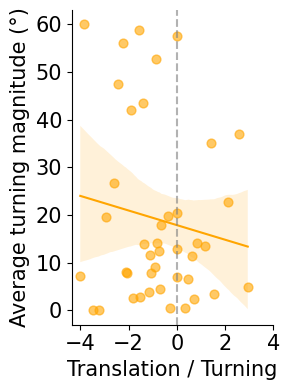

In [27]:
from scipy.stats import pearsonr

ratios = []
mean_turning_list = []

for theta, session_id in sorted(
    zip(thetas, mean_turning_magnitude_dict.keys()),
    key=lambda x: x[0][0] / x[0][1]
):
    ratio = theta[0] / theta[1]

    ratios.append(ratio)
    mean_turning_list.append(mean_turning_magnitude_dict[session_id])

log_ratios = np.log2(np.array(ratios))

plt.figure(figsize=(3, 4))

sns.regplot(
    x=log_ratios,
    y=mean_turning_list,
    scatter_kws={
        "color": "orange",
        "s": 40,
        "alpha": 0.6
    },
    line_kws={
        "color": "orange",
        "linewidth": 1.5
    },
    ci=95      # use ci=None if you don't want the confidence band
)

ax = plt.gca()

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6
)

plt.xlabel("Translation / Turning", fontsize=15)
plt.ylabel("Average turning magnitude (°)", fontsize=15)

plt.xticks(np.arange(-4, 4 + 0.1, 2), fontsize=15)
plt.yticks(fontsize=15)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

## Turning rate after slice onset

In [18]:
turning_magnitude_dict_all = {}
mean_turning_magnitude_dict_all = {}
duration = {}

for session_id, trials in head_angles_sessions.items():
    turning_magnitude_dict_all[session_id] = []
    duration[session_id] = []

    for trial_id, angles_rad in trials.items():
        angles_rad = np.array(angles_rad)

        angles_rad = angles_rad[~np.isnan(angles_rad)]
        
        # unwrap angles so 359 -> 0 transition is not a large jump
        angles_unwrapped = np.rad2deg(np.unwrap(angles_rad))

        # frame-to-fram turning
        angle_diffs = np.diff(angles_unwrapped)

        # total amount turned in degrees
        total_turning = np.sum(np.abs(angle_diffs))

        turning_magnitude_dict_all[session_id].append(total_turning)
        duration[session_id].append(len(angles_rad))

    mean_turning_magnitude_dict_all[session_id] = np.nanmean(turning_magnitude_dict_all[session_id])

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_66483/2170664102.py:26: RuntimeWarning: Mean of empty slice
  mean_turning_magnitude_dict_all[session_id] = np.nanmean(turning_magnitude_dict_all[session_id])


In [19]:
# Calculate trial-level turning rates and session means
turning_rate_dict = {}
mean_turning_rate_dict = {}

for session_id, turning_values in turning_magnitude_dict_all.items():
    turning_values = np.asarray(turning_values, dtype=float)
    durations_frames = np.asarray(duration[session_id], dtype=float)

    durations_seconds = durations_frames * 0.02

    turning_rates = np.divide(
        turning_values,
        durations_seconds,
        out=np.full_like(turning_values, np.nan, dtype=float),
        where=durations_seconds > 0
    )

    turning_rate_dict[session_id] = turning_rates
    mean_turning_rate_dict[session_id] = np.nanmean(turning_rates)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_66483/2065052078.py:19: RuntimeWarning: Mean of empty slice
  mean_turning_rate_dict[session_id] = np.nanmean(turning_rates)


In [20]:
log_ratios_turning_rate = []
mean_turning_rate_list = []

for theta, session_id in zip(thetas, mean_turning_rate_dict.keys()):
    translation_cost, turning_cost = theta

    if translation_cost <= 0 or turning_cost <= 0:
        continue

    mean_rate = mean_turning_rate_dict[session_id]

    if np.isnan(mean_rate):
        continue

    log_ratios_turning_rate.append(
        np.log2(translation_cost / turning_cost)
    )
    mean_turning_rate_list.append(mean_rate)

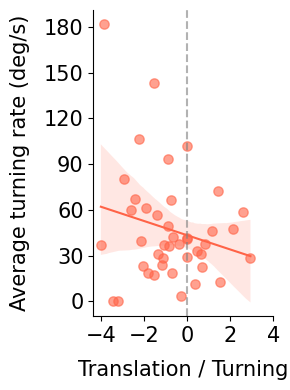

In [21]:
fig, ax = plt.subplots(figsize=(3, 4))

sns.regplot(
    x=log_ratios_turning_rate,
    y=mean_turning_rate_list,
    scatter_kws={
        "color": "tomato",
        "s": 45,
        "alpha": 0.6
    },
    line_kws={
        "color": "tomato",
        "linewidth": 1.5
    },
    ci=95,
    ax=ax
)

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6
)

ax.set_xlabel(
    r"Translation / Turning",
    fontsize=15,
    labelpad=10
)
ax.set_ylabel(
    "Average turning rate (deg/s)",
    fontsize=15,
    labelpad=10
)

ax.set_xticks(np.arange(-4, 4 + 0.1, 2))
ax.set_yticks(np.arange(0, 180 + 1, 30))
ax.tick_params(labelsize=15)

sns.despine(ax=ax, top=True, right=True)
fig.tight_layout()
plt.show()

## Turning initiation latency

In [22]:
def turn_latency_from_angles(angles_deg, dt=0.02, threshold=30):
    angles = np.array(angles_deg, dtype=float)
    angles = angles[~np.isnan(angles)]

    if len(angles) < 2:
        return np.nan

    #print(angles)
    
    # unwrap for correct differences
    angles_unwrapped = np.rad2deg(np.unwrap(np.deg2rad(angles)))
    #print(angles_unwrapped)

    # per-frame angular change (degrees per frame)
    angle_diffs = np.diff(angles_unwrapped)
    #print(angle_diffs)

    # angular velocity (deg/s)
    angular_velocity = np.abs(angle_diffs) / dt
    #print(angular_velocity)

    # first index where turning exceeds threshold
    idx = np.where(angular_velocity > threshold)[0]

    if len(idx) == 0:
        return np.nan

    first_idx = idx[0] + 1  # +1 because diff shifts index

    # convert index to time
    latency = first_idx * dt
    return latency

In [23]:
turn_latency_dict = {}

for session_id, trials in head_angles_sessions.items():
    turn_latency_dict[session_id] = []

    for trial_id, angles in trials.items():
        # e.g. first 10 samples after slice onset
        angles_window = np.array(angles[:10], dtype=float)
        angles_window = np.rad2deg(angles_window)

        latency = turn_latency_from_angles(
            angles_window,
            dt=0.02,
            threshold=30
        )

        turn_latency_dict[session_id].append(latency)

In [24]:
mean_turn_latency_dict = {
    sid: np.nanmean(vals)
    for sid, vals in turn_latency_dict.items()
}

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_66483/1635647565.py:2: RuntimeWarning: Mean of empty slice
  sid: np.nanmean(vals)


In [25]:
log_ratios_latency = []
mean_turning_latency_list = []

for theta, session_id in zip(thetas, mean_turn_latency_dict.keys()):
    translation_cost, turning_cost = theta

    if translation_cost <= 0 or turning_cost <= 0:
        continue

    mean_latency = mean_turn_latency_dict[session_id]

    if np.isnan(mean_latency):
        continue

    log_ratios_latency.append(
        np.log2(translation_cost / turning_cost)
    )
    mean_turning_latency_list.append(mean_latency)

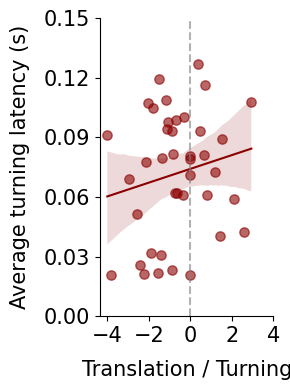

In [26]:
fig, ax = plt.subplots(figsize=(3, 4))

sns.regplot(
    x=log_ratios_latency,
    y=mean_turning_latency_list,
    scatter_kws={
        "color": "darkred",
        "s": 45,
        "alpha": 0.6
    },
    line_kws={
        "color": "darkred",
        "linewidth": 1.5
    },
    ci=95,
    ax=ax
)

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6
)

ax.set_xlabel(
    r"Translation / Turning",
    fontsize=15,
    labelpad=10
)
ax.set_ylabel(
    "Average turning latency (s)",
    fontsize=15,
    labelpad=10
)

ax.set_xticks(np.arange(-4, 4 + 0.1, 2))
ax.set_yticks(np.arange(0, 0.15 + 0.01, 0.03))
ax.tick_params(labelsize=15)

sns.despine(ax=ax, top=True, right=True)
fig.tight_layout()
plt.show()